# **Artificial Neural Networks and Deep Learning**
## Multi-Label News Classification with LSTM and Bag-of-Words



This project addresses a **multi-label news classification task** based on a dataset of 11,000 news articles. Each article can be associated with one or more of 18 semantic categories.

The objective is to design, train and evaluate a deep neural network capable of predicting the semantic labels associated with each news article by combining two different input representations:

- the textual content of the article;
- a Bag-of-Words vector containing word-frequency information.

The proposed model uses a multi-input architecture composed of an LSTM-based branch for the textual input and a dense neural branch for the Bag-of-Words representation.

## **Setup**

The following cell imports the required libraries and sets the random seeds to improve reproducibility.

In [ ]:
# Standard libraries
import os
import zipfile
import pickle as pk
import random
import re

# Data handling
import numpy as np
import pandas as pd
import itertools

# Data visualization
import matplotlib.pyplot as plt

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss

# Deep learning
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Set all random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Request deterministic TensorFlow operations
tf.config.experimental.enable_op_determinism()


print ("Libraries correctly imported")

Libraries correctly imported


Random seeds and deterministic TensorFlow operations are set to improve reproducibility across data splitting, hyperparameter search and model training. Minor differences may still occur when the notebook is executed on different hardware or software environments.


In [ ]:
# Download the dataset without displaying the download log
!wget -q https://frasca.di.unimi.it/MLDNN/input_data.zip -O input_data.zip

# Create the extraction folder
os.makedirs("unzipped_data", exist_ok=True)

# Extract the ZIP archive
with zipfile.ZipFile("input_data.zip", "r") as zip_ref:
    zip_ref.extractall("unzipped_data")

# Load the dataset
with open("unzipped_data/input_data.pkl", "rb") as f:
    data = pk.load(f)

# Extract the dataset components
texts = data["texts"]
years = data["years"]
months = data["months"]
X_bow = data["X_bow"]
Y = data["labels"]

# Check the main dataset dimensions
print("Number of texts:", len(texts))
print("Bag-of-Words shape:", X_bow.shape)
print("Labels shape:", Y.shape)

Number of texts: 11000
Bag-of-Words shape: (11000, 10000)
Labels shape: (11000, 18)


The dataset has been loaded correctly. It contains 11,000 news articles, a 10,000-dimensional Bag-of-Words representation for each article and an 18-dimensional binary target vector for multi-label classification.

## **Model Choice**
This is a **multi-input, single-output, multi-label classification task**. The dataset contains two different input representations: the original textual component and a 10,000-dimensional Bag-of-Words vector. Since these inputs have different structures and purposes, they are processed through two separate neural branches.

- The textual component is first preprocessed and then passed through an **Embedding layer followed by an LSTM layer**. The LSTM is suitable for sequential inputs such as text because it can store and update both the hidden state and the cell state. Its memory mechanism is controlled by the input, forget and output gates.

- The Bag-of-Words vector is processed through a **Multi-Layer Perceptron**, because it is a fixed-size numerical vector. The MLP is composed of fully connected layers, in which each neuron is connected to all neurons of the previous layer.

The outputs of the two branches are finally concatenated to produce the multi-label classification output.

##**Input Inspection and Preprocessing**

Before applying the preprocessing pipeline, I inspect the dataset and analyze the distribution of the target labels. This step is important to identify missing or invalid values, detect possible label imbalance and select appropriate evaluation metrics for the multi-label classification task.

In [ ]:
# Check missing or invalid values in the dataset components
missing_texts = sum(text is None or str(text).strip() == "" for text in texts)
missing_years = pd.isna(years).sum()
missing_months = pd.isna(months).sum()
missing_bow = np.isnan(X_bow).sum() if np.issubdtype(X_bow.dtype, np.floating) else 0
missing_labels = np.isnan(Y).sum() if np.issubdtype(Y.dtype, np.floating) else 0

# Check whether target values are binary
unique_label_values = np.unique(Y)

print("Missing or empty texts:", missing_texts)
print("Missing years:", missing_years)
print("Missing months:", missing_months)
print("Missing values in X_bow:", missing_bow)
print("Missing values in Y:", missing_labels)
print("Unique target values:", unique_label_values)

Missing or empty texts: 0
Missing years: 0
Missing months: 0
Missing values in X_bow: 0
Missing values in Y: 0
Unique target values: [0 1]


No missing or invalid values are detected. The Bag-of-Words matrix contains non-negative frequency values, while the target matrix contains only the binary values 0 and 1, as expected for a multi-label classification task. For this reason, no additional data-cleaning actions are required.

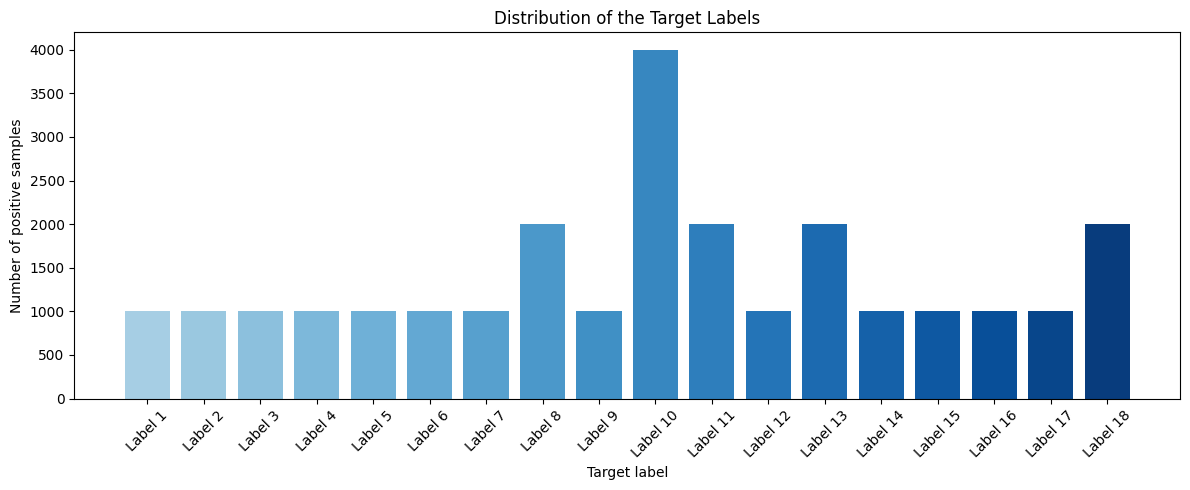

In [ ]:
# Count the positive samples for each target label
label_counts = Y.sum(axis=0)
label_names = [f"Label {i + 1}" for i in range(Y.shape[1])]

# Generate different shades of blue for the 18 labels
blue_shades = plt.cm.Blues(np.linspace(0.35, 0.95, Y.shape[1]))

# Plot the target-label distribution
plt.figure(figsize=(12, 5))
plt.bar(label_names, label_counts, color=blue_shades)

plt.xlabel("Target label")
plt.ylabel("Number of positive samples")
plt.title("Distribution of the Target Labels")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The target-label distribution is imbalanced. Most labels contain approximately **1,000 positive samples**, while Labels 8, 11, 13 and 18 contain about 2,000 positive samples, and Label 10 reaches approximately 4,000 positive samples.

Therefore, binary accuracy alone may provide an incomplete evaluation, since the most frequent labels and the large number of negative target values may dominate the result. **Precision, recall and F1-score** will also be considered in the final evaluation.

**The input data and the target labels are now separated.** The two input representations are processed through their respective preprocessing pipelines, while the target matrix is used during training to compute the loss function.

**The structured metadata are not used as model inputs**. Publication year and month may contain temporal information, but they are expected to provide only a limited semantic contribution compared to t**he textual content and the Bag-of-Words representation.** Therefore, only these two representations are used as inputs.

In [ ]:
# Select the two input representations used by the model
X_text = np.asarray(texts, dtype=object)
X_bow_input = X_bow
y = Y

### **Training, Validation and Test split**
Before fitting the preprocessing tools, I divide the dataset into **training, validation and test sets.**
1. The training set is used to learn the model parameters;
2. The validation set is used during model configuration and early stopping;
3. The test set is reserved for the final evaluation.

The split is performed **before fitting the Tokenizer and the Min-Max Scaler**. This is important because preprocessing tools must be fitted only on the training set and then applied to the validation and test sets. In this way, information from the validation or test data does not influence the preprocessing parameters, preventing data leakage.

The selected proportions are:
- **70% training**;
- **15% validation;**
- **15% test.**

In [ ]:
# Generate common indices to preserve the correspondence between inputs and targets
indices = np.arange(len(y))

# Split the dataset into 70% training and 30% temporary data
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# Split the temporary data equally into validation and test sets
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

# Create the splits for the textual input
X_text_train = X_text[train_idx]
X_text_val = X_text[val_idx]
X_text_test = X_text[test_idx]

# Create the splits for the Bag-of-Words input
X_bow_train = X_bow_input[train_idx]
X_bow_val = X_bow_input[val_idx]
X_bow_test = X_bow_input[test_idx]

# Create the target splits
y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

print("Training samples:", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:", len(test_idx))

Training samples: 7700
Validation samples: 1650
Test samples: 1650


The split produces 7,700 training samples, 1,650 validation samples and 1,650 test samples, corresponding exactly to the selected 70%-15%-15% proportions.

### **Textual-input preprocessing**

The textual component is preprocessed through the following text-cleaning operations:

1. Multiple spaces are replaced with a single space.
2. Symbols and punctuation are removed.
3. All words are converted to lowercase.
4. The cleaned text is divided into tokens.
5. Stopwords with limited semantic meaning are removed, while negations are preserved because they may affect the meaning of the sentence.



In [ ]:
# Preserve negations because they may affect the semantic meaning
stop_words = set(ENGLISH_STOP_WORDS) - {"no", "not", "nor"}

def preprocess_text(text):
    """Clean and normalize a news article."""

    # Convert the text to lowercase
    text = str(text).lower()

    # Remove symbols and punctuation
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Replace multiple spaces with a single space
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize the text
    tokens = text.split()

    # Remove stopwords while preserving relevant negations
    tokens = [token for token in tokens if token not in stop_words]

    return " ".join(tokens)

# Apply preprocessing to training, validation, and test texts
X_text_train_clean = np.array([
    preprocess_text(text) for text in X_text_train
])

X_text_val_clean = np.array([
    preprocess_text(text) for text in X_text_val
])

X_text_test_clean = np.array([
    preprocess_text(text) for text in X_text_test
])

# Display one example before and after preprocessing
print("Original text:\n", X_text_train[0])
print("\nPreprocessed text:\n", X_text_train_clean[0])

Original text:
 Adidas 'Shackle' Sneakers Cause Controversy Over Slavery Symbolism (PHOTO, POLL) The design of the JS Roundhouse Mid is nothing more than the designer Jeremy Scott’s outrageous and unique take on fashion

Preprocessed text:
 adidas shackle sneakers cause controversy slavery symbolism photo poll design js roundhouse mid designer jeremy scott s outrageous unique fashion


After the text-cleaning operations, **a dictionary** containing the unique tokens is created using only the training texts. Each token is then associated with an integer through **integer encoding.**

The same dictionary is used to transform the validation and test texts, preventing information from these sets from influencing the vocabulary construction.

In [ ]:
# Create the tokenizer
tokenizer = Tokenizer(
    lower=False,
    filters=""
)

# Build the dictionary using only the training texts
tokenizer.fit_on_texts(X_text_train_clean)

# Convert the texts into integer sequences
train_sequences = tokenizer.texts_to_sequences(X_text_train_clean)
val_sequences = tokenizer.texts_to_sequences(X_text_val_clean)
test_sequences = tokenizer.texts_to_sequences(X_text_test_clean)

# Compute the vocabulary size, including the padding index
vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary size:", vocab_size)
print("First encoded sequence:", train_sequences[0][:20])

Vocabulary size: 21198
First encoded sequence: [5135, 11645, 5136, 970, 1879, 11646, 11647, 67, 420, 1119, 11648, 11649, 2688, 785, 6263, 1738, 1, 4366, 786, 59]


The vocabulary contains the unique tokens learned from the training texts. An additional index is reserved for padding.

The final step is **padding**. This technique is applied so that all textual sequences have the same length of 100 tokens. Zeros are added at the end of shorter sequences, while no truncation is required because the maximum original text length is already 100 words.

In [ ]:
# Define the fixed sequence length
MAX_LENGTH = 100

# Apply post-padding with zeros
X_text_train_pad = pad_sequences(
    train_sequences,
    maxlen=MAX_LENGTH,
    padding="post"
)

X_text_val_pad = pad_sequences(
    val_sequences,
    maxlen=MAX_LENGTH,
    padding="post"
)

X_text_test_pad = pad_sequences(
    test_sequences,
    maxlen=MAX_LENGTH,
    padding="post"
)

print("Training text shape:", X_text_train_pad.shape)
print("Validation text shape:", X_text_val_pad.shape)
print("Test text shape:", X_text_test_pad.shape)

Training text shape: (7700, 100)
Validation text shape: (1650, 100)
Test text shape: (1650, 100)


After padding, each row is an integer-encoded sequence of exactly 100 positions.

Before being processed by the LSTM layer, the integer-encoded sequences are passed through an **Embedding layer**. The Embedding layer transforms each integer token into a dense numerical vector that can be learned during training.

### **Bag-of-Words input preprocessing**

The Bag-of-Words input is a 10,000-dimensional numerical vector, where each value represents the absolute frequency of a word in the corresponding news article.

Min-Max normalization is applied to rescale the feature values into the interval $[0,1]$. The scaler is fitted only on the training set and then applied to the validation and test sets in order to avoid data leakage.


In [ ]:
# Convert the Bag-of-Words data to float32 to reduce memory usage
X_bow_train = X_bow_train.astype(np.float32, copy=False)
X_bow_val = X_bow_val.astype(np.float32, copy=False)
X_bow_test = X_bow_test.astype(np.float32, copy=False)

# Fit the Min-Max scaler only on the training set
bow_scaler = MinMaxScaler(copy=False)

X_bow_train_scaled = bow_scaler.fit_transform(X_bow_train)
X_bow_val_scaled = bow_scaler.transform(X_bow_val)
X_bow_test_scaled = bow_scaler.transform(X_bow_test)

# Check the final shapes and value range
print("Training Bag-of-Words shape:", X_bow_train_scaled.shape)
print("Validation Bag-of-Words shape:", X_bow_val_scaled.shape)
print("Test Bag-of-Words shape:", X_bow_test_scaled.shape)
print(
    "Training value range:",
    X_bow_train_scaled.min(),
    X_bow_train_scaled.max()
)

Training Bag-of-Words shape: (7700, 10000)
Validation Bag-of-Words shape: (1650, 10000)
Test Bag-of-Words shape: (1650, 10000)
Training value range: 0.0 1.0


After normalization, the Bag-of-Words matrices preserve their original dimensionality, while the training values are rescaled into the interval $[0,1]$.

### **Final input representations**
After preprocessing, the textual input is represented by an integer sequence with:

- Shape: $(100,)$
- Domain: $\{0,1,\ldots,V-1\}$, where 0 is reserved for padding and $V$ is the vocabulary size including the padding index.

After the Embedding layer, each token is mapped to a dense vector. Therefore, the textual representation has shape:

$$
(100,\text{embedding dimension})
$$

After Min-Max normalization, the Bag-of-Words input is represented by a numerical vector with:

- Shape: $(10000,)$
- Domain: $[0,1]$


## **Model configuration**

This section describes the main configuration choices of the model, including weight initialization, regularization, optimizer, loss function and hyperparameters. These choices are then implemented in a model-building function, which allows different hyperparameter configurations to be tested consistently.

The model is composed of two separate branches:

1. The textual input is processed by an **Embedding layer** followed by an **LSTM layer**.
2. The Bag-of-Words input is processed by a **Multi-Layer Perceptron** containing a fully connected Dense layer.

The representations produced by the two branches are concatenated and passed through an additional Dense layer before generating the final multi-label output.

The following diagram summarizes the overall architecture of the proposed multi-input neural network.

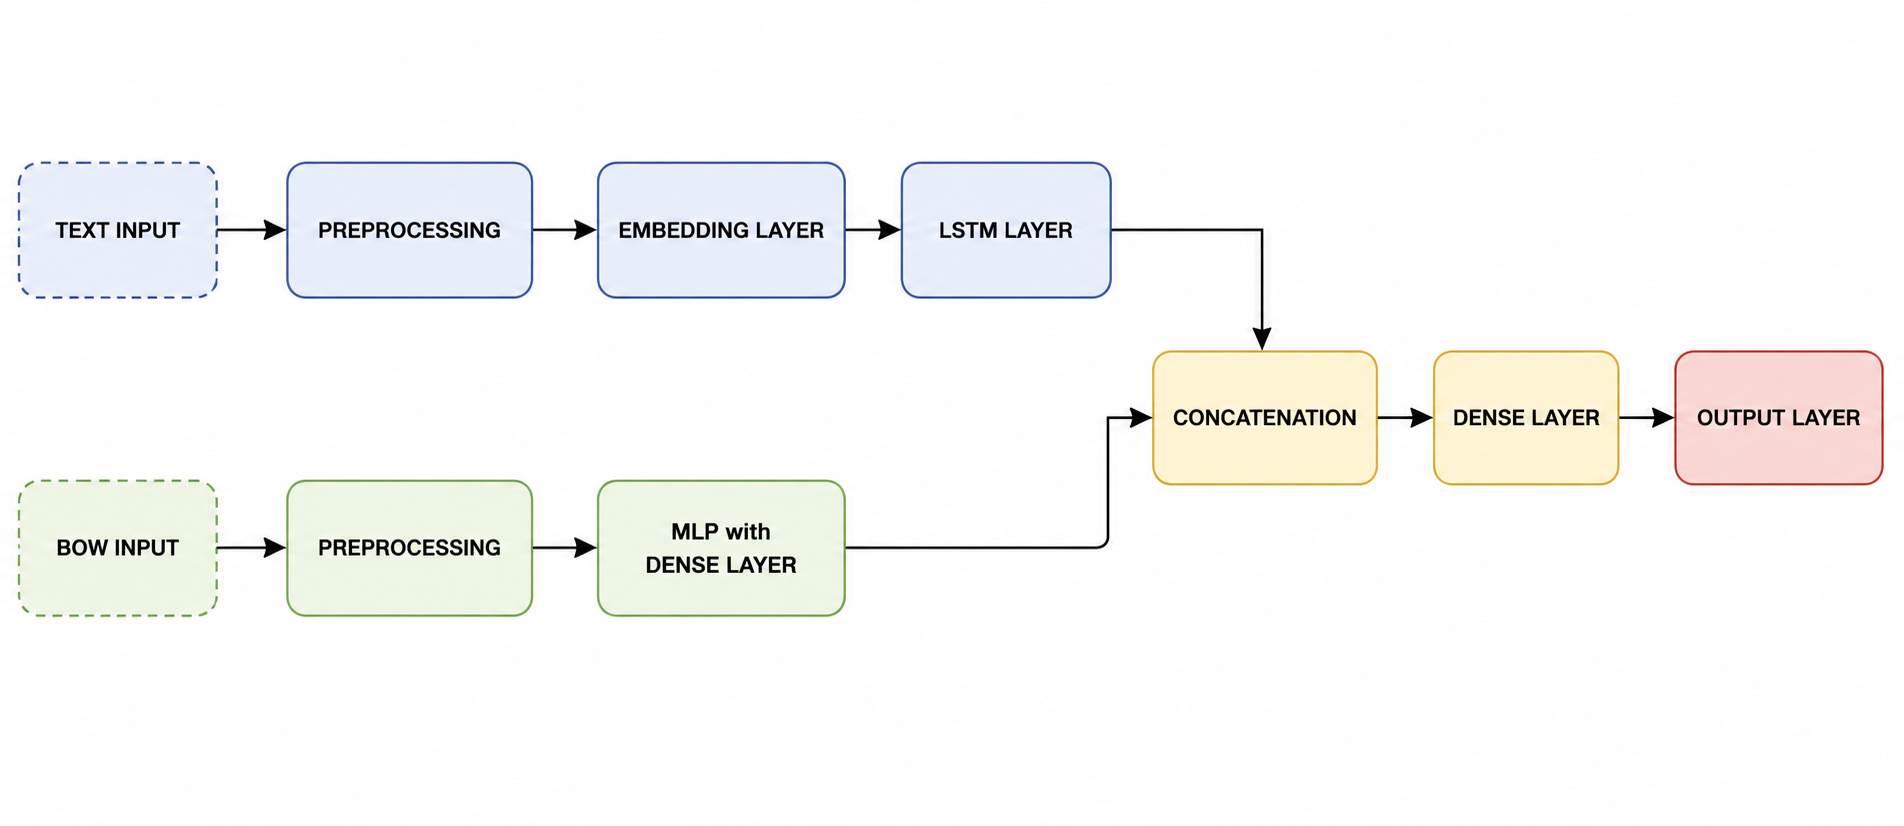

### **Output Layer and Loss function**

The output of the model is produced by a fully connected Dense layer with 18 neurons:

$$
\text{Dense}(18, \text{activation}=\text{"sigmoid"})
$$

Each neuron corresponds to one of the 18 semantic categories.

Since this is a multi-label classification task, the categories are not mutually exclusive: the same news article may be associated with more than one label at the same time. For this reason, the sigmoid activation function is applied independently to each output neuron:

$$
\hat{y}_k = \frac{1}{1 + e^{-z_k}}
$$

For each label \(k\), the model produces a value:

$$
\hat{y}_k \in [0,1]
$$

This value can be interpreted as the probability that the corresponding category is associated with the news article.

A threshold equal to 0.5 is then applied to obtain the final binary prediction:

$$
\hat{y}_k \geq 0.5 \Rightarrow \text{label } 1
$$

$$
\hat{y}_k < 0.5 \Rightarrow \text{label } 0
$$

This procedure is independently applied to all 18 output neurons, producing an 18-dimensional binary vector.

Because each output represents an independent binary prediction, the model is trained using **Binary Cross-Entropy**. For one label, the loss is:

$$
\mathcal{L}(y,\hat{y}) =
-\left[
y\log(\hat{y}) +
(1-y)\log(1-\hat{y})
\right]
$$

The loss is computed independently for each label and then averaged across labels and samples.

### **Initialization**

Different weight-initialization strategies are used according to the activation functions adopted by the model.

- For the LSTM layer, **Glorot/Xavier uniform initialization** is used. This choice is appropriate because the LSTM internally relies mainly on sigmoid and tanh activation functions. Xavier initialization helps keep the variance of activations and gradients stable during training.

- For the Dense hidden layers with ReLU activation, **He normal initialization** is used. This initialization strategy is suitable for ReLU-based layers because it helps maintain stable activations during forward and backward propagation.

- For the final output layer with sigmoid activation, **Glorot/Xavier uniform initialization** is used.

### **Regularization**

To reduce the risk of overfitting, the model uses **dropout** and **early stopping**. Overfitting occurs when the model learns the training data too closely and loses the ability to generalize to unseen data.

Dropout randomly deactivates a fraction of neurons during training, preventing the model from relying excessively on the same units. The dropout rate is treated as a hyperparameter, with candidate values of **0.2** and **0.3**.

Early stopping monitors the validation loss and stops the training process when the validation loss no longer improves. The model is trained for a maximum of 50 epochs, but training can terminate earlier if no improvement is observed. The weights corresponding to the best validation loss are restored at the end of training.

A patience value of 2 is used to avoid unnecessary training once the validation loss stops improving.

### **Optimizer**

The model is trained using the **Adam optimizer**, which combines momentum-based updates with adaptive learning rates. This allows each model parameter to be updated with an individually adjusted learning rate and generally provides stable and efficient convergence.

The initial learning rate is treated as a hyperparameter, with candidate values of **0.001** and **0.0005**.


The following function implements the configuration choices described above. It builds and compiles the complete multi-input neural network while receiving the tunable hyperparameters as arguments.

This structure allows the same architecture to be generated consistently with different values of LSTM units, Dense units, dropout rate and learning rate during hyperparameter tuning.

In [ ]:
# Build and compile the multi-input neural network
def build_model(
    embedding_dim,
    lstm_units,
    dense_units,
    dropout_rate,
    learning_rate
):
    # ---------------------------------------------------------
    # TEXTUAL-INPUT BRANCH

    # Input sequence with fixed length equal to 100 tokens
    text_input = Input(
        shape=(MAX_LENGTH,),
        name="text_input"
    )

    # Transform each integer token into a dense embedding vector
    text_features = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True,
        name="embedding_layer"
    )(text_input)

    # Process the sequential textual representation
    # Glorot uniform initialization is used for the LSTM weights
    text_features = LSTM(
        units=lstm_units,
        kernel_initializer="glorot_uniform",
        name="lstm_layer"
    )(text_features)

    # Apply dropout to reduce overfitting in the textual branch
    text_features = Dropout(
        rate=dropout_rate,
        name="text_dropout"
    )(text_features)

    # ---------------------------------------------------------
    # BAG-OF-WORDS BRANCH

    # Input vector containing the 10,000 normalized word frequencies
    bow_input = Input(
        shape=(X_bow_train_scaled.shape[1],),
        name="bow_input"
    )

    # Process the Bag-of-Words vector through a Dense layer
    # He normal initialization is used because the activation is ReLU
    bow_features = Dense(
        units=dense_units,
        activation="relu",
        kernel_initializer="he_normal",
        name="bow_dense_layer"
    )(bow_input)

    # Apply dropout to reduce overfitting in the Bag-of-Words branch
    bow_features = Dropout(
        rate=dropout_rate,
        name="bow_dropout"
    )(bow_features)

    # ---------------------------------------------------------
    # FEATURE FUSION


    # Concatenate the representations learned by the two branches
    combined_features = Concatenate(
        name="concatenation_layer"
    )([text_features, bow_features])

    # Process the combined representation through a Dense layer
    combined_features = Dense(
        units=dense_units,
        activation="relu",
        kernel_initializer="he_normal",
        name="combined_dense_layer"
    )(combined_features)

    # Apply dropout after the concatenation branch
    combined_features = Dropout(
        rate=dropout_rate,
        name="combined_dropout"
    )(combined_features)

    # ---------------------------------------------------------
    # MULTI-LABEL OUTPUT

    # Produce one independent probability for each of the 18 labels
    output = Dense(
        units=18,
        activation="sigmoid",
        kernel_initializer="glorot_uniform",
        name="output_layer"
    )(combined_features)

    # Create the complete multi-input model
    model = Model(
        inputs=[text_input, bow_input],
        outputs=output,
        name="multi_label_news_classifier"
    )

    # Compile the model using Adam and Binary Cross-Entropy
    model.compile(
        optimizer= Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model

### **Hyperparameter Tuning**

The main hyperparameters considered are the number of LSTM units, the number of neurons in the Dense layers, the dropout rate, the learning rate and the batch size.

The following candidate values are evaluated:

- LSTM units: 32 or 64
- Dense units: 32 or 64
- Dropout rate: 0.2 or 0.3
- Learning rate: 0.001 or 0.0005
- Batch size: 32, 64 or 128

The configurations are compared using the minimum validation loss.

A **limited Random Search** is used to sample three configurations from the complete set of possible hyperparameter combinations. This approach reduces the computational cost compared to an exhaustive Grid Search, which would require training all possible configurations.

The sampling process is reproducible because a fixed random seed is used.

In [ ]:
# Define the candidate hyperparameter values
# Define the candidate values proposed in the written solution
search_space = {
    "lstm_units": [32,64],
    "dense_units": [32, 64],
    "dropout_rate": [0.2, 0.3],
    "learning_rate": [0.001, 0.0005],
    "batch_size": [32, 64, 128]
}

EMBEDDING_DIM = 64

In [ ]:
# Generate all possible hyperparameter combinations
all_configurations = [
    dict(zip(search_space.keys(), values))
    for values in itertools.product(*search_space.values())
]

# Randomly select three reproducible configurations
random_generator = random.Random(42)

random_search_configs = random_generator.sample(
    all_configurations,
    k=3
)


random_search_configs

[{'lstm_units': 64,
  'dense_units': 64,
  'dropout_rate': 0.2,
  'learning_rate': 0.0005,
  'batch_size': 64},
 {'lstm_units': 32,
  'dense_units': 32,
  'dropout_rate': 0.3,
  'learning_rate': 0.001,
  'batch_size': 64},
 {'lstm_units': 32,
  'dense_units': 32,
  'dropout_rate': 0.2,
  'learning_rate': 0.001,
  'batch_size': 64}]

To keep the tuning phase computationally efficient, Random Search is performed on reproducible subsets containing 2,000 training samples and 500 validation samples.

These subsets are used only for hyperparameter selection. The final model is then trained on the complete training set.

In [ ]:
# Create reproducible subsets used only during hyperparameter tuning
rng = np.random.default_rng(42)

TUNING_TRAIN_SIZE = 2000
TUNING_VAL_SIZE = 500

tuning_train_idx = rng.choice(
    len(y_train),
    size=TUNING_TRAIN_SIZE,
    replace=False
)

tuning_val_idx = rng.choice(
    len(y_val),
    size=TUNING_VAL_SIZE,
    replace=False
)

# Textual-input subsets
X_text_train_tuning = X_text_train_pad[tuning_train_idx]
X_text_val_tuning = X_text_val_pad[tuning_val_idx]

# Bag-of-Words subsets
X_bow_train_tuning = X_bow_train_scaled[tuning_train_idx]
X_bow_val_tuning = X_bow_val_scaled[tuning_val_idx]

# Target subsets
y_train_tuning = y_train[tuning_train_idx]
y_val_tuning = y_val[tuning_val_idx]

print("Tuning training samples:", len(y_train_tuning))
print("Tuning validation samples:", len(y_val_tuning))

Tuning training samples: 2000
Tuning validation samples: 500


In [ ]:
# Use early stopping during hyperparameter tuning
tuning_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    mode="min"
)

Early stopping is also used during hyperparameter tuning to avoid unnecessary training when the validation loss stops improving.

In [ ]:
# Store the tuning results
tuning_results = []

best_config = None
best_val_loss = np.inf

for trial, config in enumerate(random_search_configs, start=1):

    # Clear the previous TensorFlow model from memory
    tf.keras.backend.clear_session()

    # Set a reproducible seed for the current trial
    trial_seed = SEED + trial
    tf.keras.utils.set_random_seed(trial_seed)

    print(f"Trial {trial}/{len(random_search_configs)}")
    print(config)

    # Build the model using the current configuration
    trial_model = build_model(
        embedding_dim=64,
        lstm_units=config["lstm_units"],
        dense_units=config["dense_units"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"]
    )

    # Train on the reduced tuning subsets
    trial_history = trial_model.fit(
        {
            "text_input": X_text_train_tuning,
            "bow_input": X_bow_train_tuning
        },
        y_train_tuning,
        validation_data=(
            {
                "text_input": X_text_val_tuning,
                "bow_input": X_bow_val_tuning
            },
            y_val_tuning
        ),
        epochs=4,
        batch_size=config["batch_size"],
        callbacks=[tuning_early_stopping],
        verbose=0
    )

    # Retrieve the minimum validation loss
    trial_val_loss = min(trial_history.history["val_loss"])

    tuning_results.append({
        **config,
        "validation_loss": trial_val_loss
    })

    print(f"Best validation loss: {trial_val_loss:.4f}\n")

    # Update the best configuration
    if trial_val_loss < best_val_loss:
        best_val_loss = trial_val_loss
        best_config = config.copy()

    # Release memory before the next trial
    del trial_model
    del trial_history

Trial 1/3
{'lstm_units': 64, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 64}
Best validation loss: 0.3569

Trial 2/3
{'lstm_units': 32, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64}
Best validation loss: 0.3697

Trial 3/3
{'lstm_units': 32, 'dense_units': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
Best validation loss: 0.3811



The Random Search compares three hyperparameter configurations using the minimum validation loss. **The configuration associated with the lowest validation loss is selected for the construction and training of the final model.**

In [ ]:
# Display the tuning results ordered by validation loss
tuning_results_df = pd.DataFrame(tuning_results).sort_values(
    by="validation_loss"
).reset_index(drop=True)

display(tuning_results_df)

print("Best hyperparameter configuration:")
print(best_config)

print("\nBest validation loss:")
print(round(best_val_loss, 4))

,lstm_units,dense_units,dropout_rate,learning_rate,batch_size,validation_loss
0,64,64,0.2,0.0005,64,0.356882
1,32,32,0.3,0.0010,64,0.369705
2,32,32,0.2,0.0010,64,0.381147


Best hyperparameter configuration:
{'lstm_units': 64, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 64}

Best validation loss:
0.3569


Among the three sampled configurations, the model with 64 LSTM units, 64 Dense units, a dropout rate of 0.2, a learning rate of 0.0005 and a batch size of 64 achieved the lowest validation loss. This configuration is therefore selected to build and train the final model.


### **Final Model Training with Best Hyperparameters**

The final model is built using the hyperparameter configuration associated with the lowest validation loss during Random Search.

In [ ]:
# Clear previous TensorFlow models from memory
tf.keras.backend.clear_session()

# Set a reproducible seed before building the final model
tf.keras.utils.set_random_seed(SEED)

# Build the final model using the best hyperparameter configuration
final_model = build_model(
    embedding_dim=64,
    lstm_units=best_config["lstm_units"],
    dense_units=best_config["dense_units"],
    dropout_rate=best_config["dropout_rate"],
    learning_rate=best_config["learning_rate"]
)

# Display the final model architecture
final_model.summary()

Model: "multi_label_news_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_layer     │ (None, 100, 64)   │  1,356,672 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 100)       │          0 │ text_input[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bow_input           │ (None, 10000)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer (LSTM)   │ (None, 64)        │     33,024 │ embedding_layer[… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bow_dense_layer     │ (None, 64)        │    640,064 │ bow_input[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_dropout        │ (None, 64)        │          0 │ lstm_layer[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bow_dropout         │ (None, 64)        │          0 │ bow_dense_layer[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenation_layer │ (None, 128)       │          0 │ text_dropout[0][… │
│ (Concatenate)       │                   │            │ bow_dropout[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_dense_lay… │ (None, 64)        │      8,256 │ concatenation_la… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ combined_dropout    │ (None, 64)        │          0 │ combined_dense_l… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 18)        │      1,170 │ combined_dropout… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,039,186 (7.78 MB)

 Trainable params: 2,039,186 (7.78 MB)

 Non-trainable params: 0 (0.00 B)

The model summary shows the two-input architecture of the network. The textual branch processes the padded token sequences through an Embedding layer and an LSTM layer, while the Bag-of-Words branch processes the normalized frequency vectors through a Dense layer.

The two learned representations are concatenated and passed through a final Dense layer before producing the 18 output probabilities.

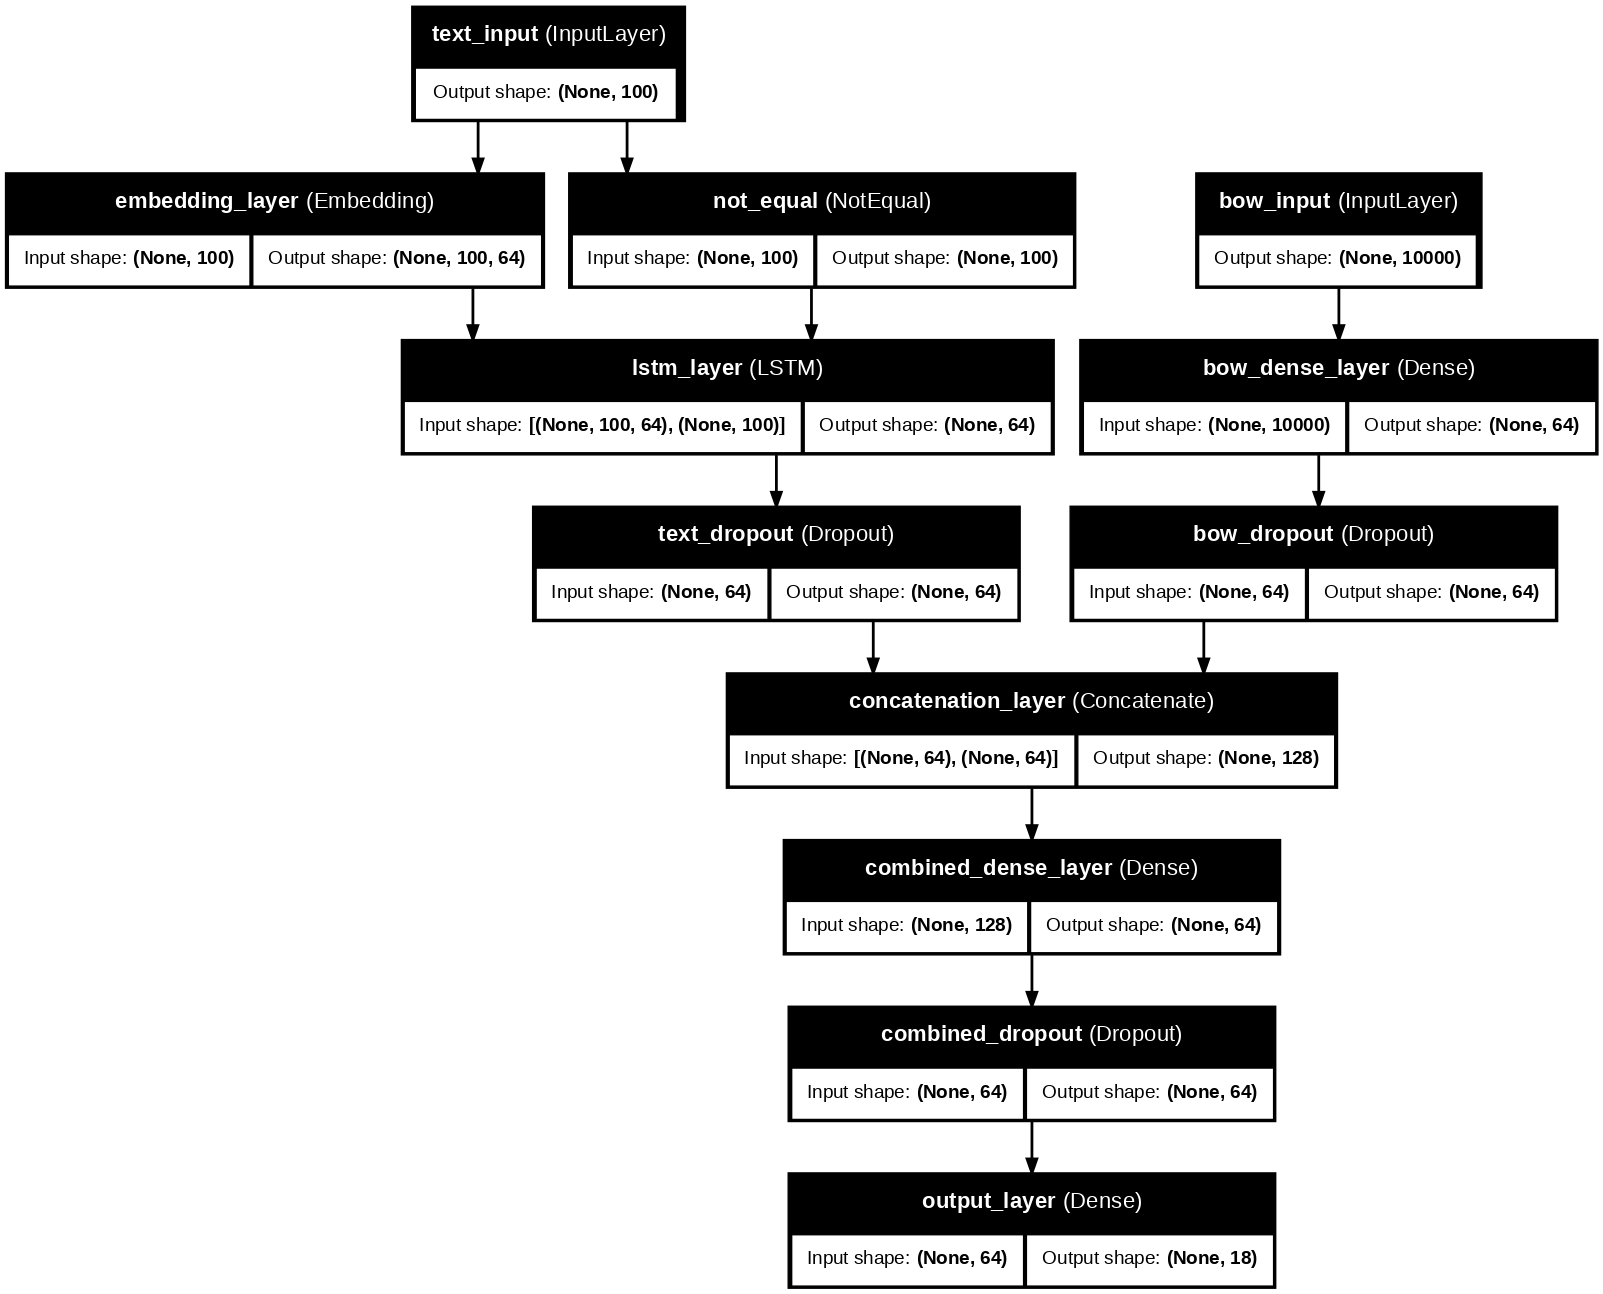

In [ ]:
# Generate the final model graph
tf.keras.utils.plot_model(
    final_model,
    to_file="final_model_graph.png",
    show_shapes=True,
    show_layer_names=True,
    show_dtype=False,
    dpi=100
)

from IPython.display import Image, display

# Display the final model graph
display(Image(filename="final_model_graph.png"))

The `NotEqual` operation is automatically generated by Keras because the Embedding layer uses `mask_zero=True`. It creates a mask that allows the LSTM to ignore the zero values introduced by padding.

The final model is trained on the complete training set, while the validation set is used exclusively to monitor the validation loss. Training is allowed to run for a maximum of 50 epochs. However, early stopping interrupts the process when the validation loss does not improve for two consecutive epochs and restores the weights associated with the best validation loss.

In [ ]:
# Stop training when the validation loss no longer improves
final_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
    mode="min"
)

# Train the final model using the best hyperparameter configuration
history = final_model.fit(
    x={
        "text_input": X_text_train_pad,
        "bow_input": X_bow_train_scaled
    },
    y=y_train,
    validation_data=(
        {
            "text_input": X_text_val_pad,
            "bow_input": X_bow_val_scaled
        },
        y_val
    ),
    epochs=50,
    batch_size=best_config["batch_size"],
    callbacks=[final_early_stopping],
    verbose=1
)

Epoch 1/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 22s 147ms/step - binary_accuracy: 0.8335 - loss: 0.4759 - precision: 0.2008 - recall: 0.1083 - val_binary_accuracy: 0.8733 - val_loss: 0.3617 - val_precision: 0.7500 - val_recall: 7.9681e-04
Epoch 2/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 16s 107ms/step - binary_accuracy: 0.8799 - loss: 0.3505 - precision: 0.7185 - recall: 0.0761 - val_binary_accuracy: 0.8860 - val_loss: 0.3156 - val_precision: 0.8706 - val_recall: 0.1179
Epoch 3/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 13s 108ms/step - binary_accuracy: 0.8969 - loss: 0.2827 - precision: 0.8474 - recall: 0.2206 - val_binary_accuracy: 0.8971 - val_loss: 0.2627 - val_precision: 0.8583 - val_recall: 0.2252
Epoch 4/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - binary_accuracy: 0.9165 - loss: 0.2123 - precision: 0.8859 - recall: 0.3862 - val_binary_accuracy: 0.9102 - val_loss: 0.2253 - val_precision: 0.8665 - val_recall: 0.3448
Epoch 5/50
121/121 ━━━━━━━━━━━━━━━━━━━━ 13s 109ms/step - binary_accuracy: 0.9422 - loss:

The final training process stopped after 8 epochs. The training Binary Cross-Entropy continuously decreased, while **the validation loss reached its minimum value at epoch 6** and then increased for two consecutive epochs.

This divergence indicates the beginning of overfitting: the model continued to improve on the training data, but its performance on the validation set started to deteriorate. Therefore, early stopping interrupted the training after epoch 8 and restored the weights obtained at epoch 6, corresponding to the best validation loss.

## **Model Evaluation**

The final model is evaluated on the test set, which was not used during training, validation or hyperparameter tuning.

Since this is an imbalanced multi-label classification problem, the evaluation focuses on micro-averaged and macro-averaged metrics in addition to binary accuracy.

- **Micro-averaged precision, recall and F1-score** aggregate the predictions across all labels before computing the metric. This provides an overall measure of the model's ability to correctly predict positive labels across the entire dataset.

- **Macro-averaged F1-score** is computed separately for each label and then averaged. This is useful because each category receives the same importance, making performance on less frequent labels more visible.

Binary accuracy is also reported, but it is interpreted as a secondary metric because the target matrix contains many zero values.

In [ ]:
# Generate probability predictions on the test set
y_prob = final_model.predict(
    {
        "text_input": X_text_test_pad,
        "bow_input": X_bow_test_scaled
    },
    verbose=0
)

# Convert probabilities into binary predictions
THRESHOLD = 0.5
y_pred = (y_prob >= THRESHOLD).astype(int)

# Compute multi-label evaluation metrics
test_precision_micro = precision_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

test_recall_micro = recall_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

test_f1_micro = f1_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

test_f1_macro = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# Display the final evaluation results
evaluation_results = pd.DataFrame({
    "Metric": [
        "Micro Precision",
        "Micro Recall",
        "Micro F1-score",
        "Macro F1-score"
    ],
    "Value": [
        test_precision_micro,
        test_recall_micro,
        test_f1_micro,
        test_f1_macro
    ]
})

display(evaluation_results)

,Metric,Value
0,Micro Precision,0.832579
1,Micro Recall,0.534178
2,Micro F1-score,0.650804
3,Macro F1-score,0.594664


In [ ]:
# Evaluate the compiled Keras metrics on the test set
test_loss, test_binary_accuracy, test_precision, test_recall = final_model.evaluate(
    {
        "text_input": X_text_test_pad,
        "bow_input": X_bow_test_scaled
    },
    y_test,
    verbose=0
)

print("Test Binary Cross-Entropy:", round(test_loss, 4))
print("Test Binary Accuracy:", round(test_binary_accuracy, 4))
print("Test Precision:", round(test_precision, 4))
print("Test Recall:", round(test_recall, 4))

Test Binary Cross-Entropy: 0.2025
Test Binary Accuracy: 0.9269
Test Precision: 0.8326
Test Recall: 0.5342


The model achieves a **Micro Precision of approximately 0.83**, meaning that about 83% of the labels predicted as positive are correct.

The **Micro Recall is approximately 0.53**, indicating that the model identifies about 53% of all true positive labels. Precision is therefore considerably higher than recall: the model produces relatively reliable positive predictions, but it remains conservative and misses part of the relevant semantic categories.

The **Micro F1-score is approximately 0.65**, representing the harmonic balance between precision and recall. The **Macro F1-score is lower, approximately 0.59**, suggesting that the model performs less effectively on some of the less frequent labels.

Binary accuracy reaches approximately 0.926, but this value is interpreted as a secondary metric because most entries in the multi-label target matrix are equal to zero.

Finally, the **test Binary Cross-Entropy is approximately 0.20**, representing the probability-based prediction error on unseen test samples.

Overall, **the model successfully combines sequential textual information and Bag-of-Words features** to perform multi-label news classification. The results show good precision, while recall and macro-F1 indicate that **some positive and less frequent labels remain more difficult to identify**.